# 02 — Cross-venue basis & funding (P1)

**What this notebook answers**

- HL perp vs Binance perp basis: how does it move? mean-reverting?
- HL perp vs HL spot (UBTC) and HL perp vs Binance spot basis.
- Funding rate path on both venues; HL is **hourly**, Binance **8h**, so we annualize for parity.
- Funding-implied carry vs realized basis.

These are the inputs for an MM hedge model: if the basis is wide and stable,
inventory cost is the dominant edge. If it's noisy and zero-mean, basis
arbitrage drowns out passive MM PnL.

In [1]:
from hlanalysis.analysis import duck, glob_for, load_df, set_mpl_defaults
import pandas as pd, numpy as np, matplotlib.pyplot as plt
set_mpl_defaults()

def mid_resampled(venue, product_type, symbol, freq='1s'):
    g = glob_for(venue=venue, product_type=product_type, event='bbo', symbol=symbol)
    df = load_df(f'''
        SELECT exchange_ts, (bid_px+ask_px)/2.0 AS mid
        FROM read_parquet('{g}', hive_partitioning=true)
        WHERE bid_px>0 AND ask_px>0
        ORDER BY exchange_ts
    ''')
    if df.empty: return df
    df['t'] = pd.to_datetime(df.exchange_ts, unit='ns', utc=True)
    df = df.set_index('t')[['mid']].resample(freq).last().ffill().dropna()
    return df

hl_perp   = mid_resampled('hyperliquid','perp','BTC').rename(columns={'mid':'hl_perp'})
bn_perp   = mid_resampled('binance','perp','BTCUSDT').rename(columns={'mid':'bn_perp'})
bn_spot   = mid_resampled('binance','spot','BTCUSDT').rename(columns={'mid':'bn_spot'})
joined = hl_perp.join([bn_perp, bn_spot], how='inner')
print(joined.tail()); print('rows:', len(joined))

                           hl_perp   bn_perp    bn_spot
t                                                      
2026-05-05 17:23:27+00:00  81375.5  81361.55  81406.465
2026-05-05 17:23:28+00:00  81375.5  81361.55  81406.465
2026-05-05 17:23:29+00:00  81375.5  81361.55  81406.465
2026-05-05 17:23:30+00:00  81375.5  81361.55  81406.465
2026-05-05 17:23:31+00:00  81375.5  81361.55  81406.465
rows: 33975


## 1. Mid prices, all venues, overlaid

Eyeball check: do the curves track? Any structural offset? For BTC at the same
moment they should be visually indistinguishable at this zoom.

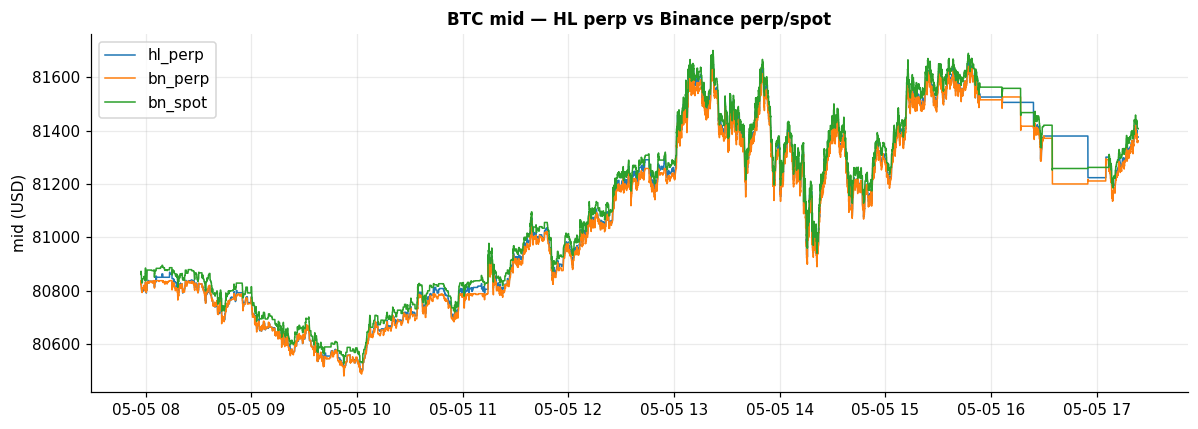

In [2]:
fig, ax = plt.subplots(figsize=(11,4))
for c in joined.columns:
    ax.plot(joined.index, joined[c], label=c, lw=1)
ax.set_ylabel('mid (USD)'); ax.legend(loc='upper left'); ax.set_title('BTC mid — HL perp vs Binance perp/spot')
plt.tight_layout(); plt.show()

## 2. Basis time series (HL perp vs Binance perp / spot)

Two flavors:
- **HL_perp − Binance_perp** : carry vs futures-curve term. Should hover near zero, mean-reverting.
- **HL_perp − Binance_spot** : carry vs cash. Should equal funding-implied carry over the holding horizon.

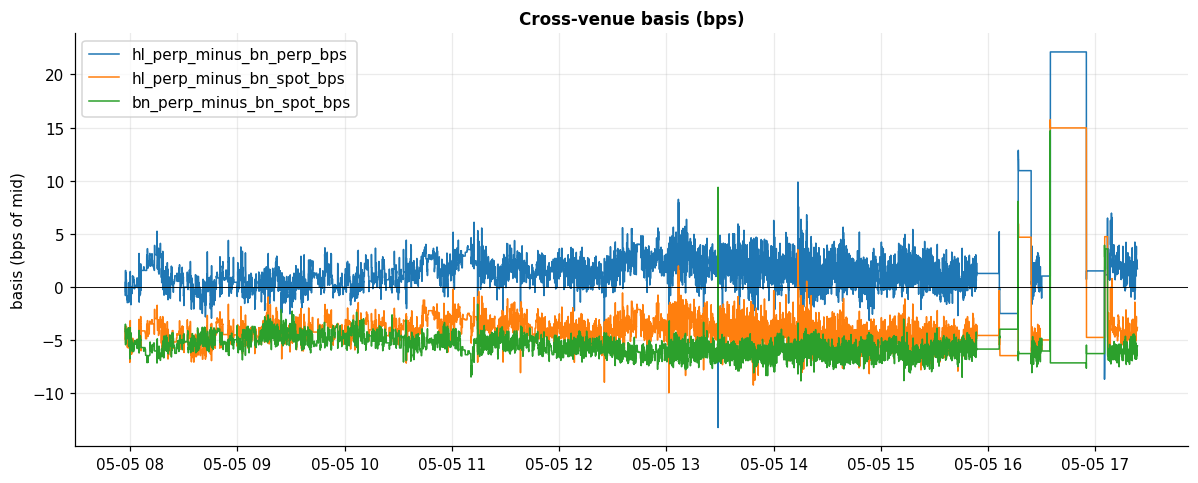

                               mean       std        min        5%       50%  \
hl_perp_minus_bn_perp_bps  2.205607  4.159995 -13.207592 -0.551973  1.431316   
hl_perp_minus_bn_spot_bps -3.368400  3.825956  -9.945254 -5.731346 -4.215355   
bn_perp_minus_bn_spot_bps -5.572593  1.019789  -8.828909 -7.125499 -5.685314   

                                95%        max  
hl_perp_minus_bn_perp_bps  5.373587  22.112083  
hl_perp_minus_bn_spot_bps  4.689612  15.750474  
bn_perp_minus_bn_spot_bps -3.975258  14.710493  


In [3]:
basis = pd.DataFrame({
    'hl_perp_minus_bn_perp_bps': 1e4*(joined.hl_perp - joined.bn_perp)/joined.bn_perp,
    'hl_perp_minus_bn_spot_bps': 1e4*(joined.hl_perp - joined.bn_spot)/joined.bn_spot,
    'bn_perp_minus_bn_spot_bps': 1e4*(joined.bn_perp - joined.bn_spot)/joined.bn_spot,
})

fig, ax = plt.subplots(figsize=(11,4.5))
for c in basis.columns:
    ax.plot(basis.index, basis[c], label=c, lw=1)
ax.axhline(0, color='k', lw=0.6)
ax.set_ylabel('basis (bps of mid)')
ax.legend(loc='upper left')
ax.set_title('Cross-venue basis (bps)')
plt.tight_layout(); plt.show()

print(basis.describe(percentiles=[.01,.05,.5,.95,.99]).T[['mean','std','min','5%','50%','95%','max']])

## 3. Basis distribution & half-life of mean reversion

A symmetric tight distribution and short half-life ⇒ classic stat-arb regime;
asymmetric or fat-tailed ⇒ regime in transition. Half-life from AR(1) on
deviations from mean.

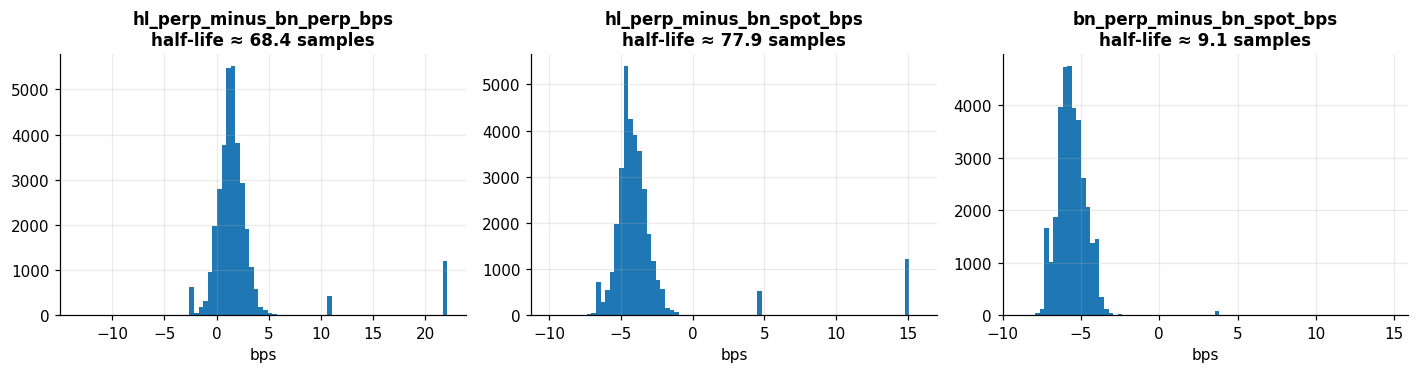

In [4]:
def half_life(s):
    s = s.dropna()
    if len(s) < 50: return np.nan
    s_lag = s.shift(1).dropna()
    s_diff = (s - s_lag).dropna()
    s_lag = s_lag.loc[s_diff.index]
    # OLS  Δs = a + b*s_lag
    import numpy.linalg as la
    X = np.column_stack([np.ones_like(s_lag), s_lag.values])
    beta, *_ = la.lstsq(X, s_diff.values, rcond=None)
    b = beta[1]
    if b >= 0: return np.nan
    return -np.log(2)/np.log(1+b)

fig, axes = plt.subplots(1, 3, figsize=(13,3.5))
for ax, c in zip(axes, basis.columns):
    s = basis[c].dropna()
    ax.hist(s, bins=80)
    hl = half_life(s)
    ax.set_title(f'{c}\nhalf-life ≈ {hl:.1f} samples' if hl==hl else c)
    ax.set_xlabel('bps')
plt.tight_layout(); plt.show()

## 4. Funding paths

HL funding is hourly, Binance is 8-hourly. We plot both as **annualized %**:
`annual = funding_rate * periods_per_year`. HL: ×24×365, Binance: ×3×365.

HL funding rows: 58276  BN funding rows: 18440


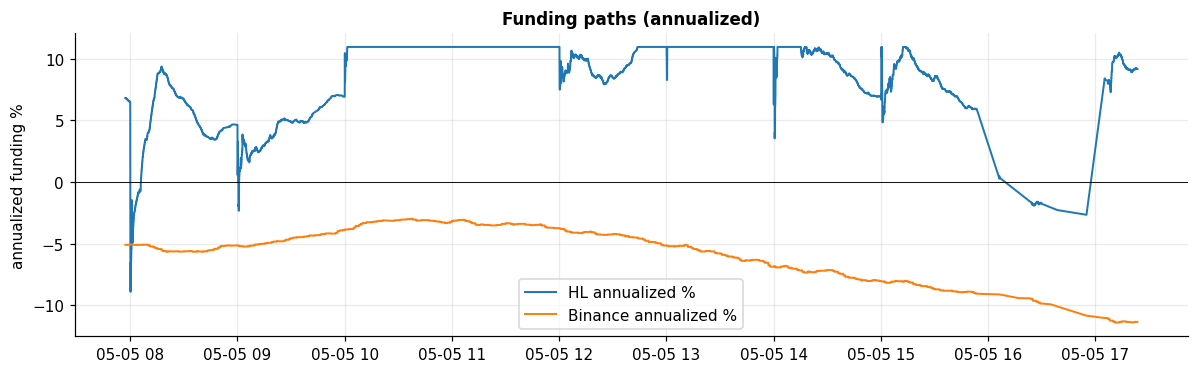

In [5]:
def funding_df(venue, symbol, periods_per_day):
    g = glob_for(venue=venue, product_type='perp', event='funding', symbol=symbol)
    df = load_df(f'''
        SELECT exchange_ts, funding_rate, premium
        FROM read_parquet('{g}', hive_partitioning=true)
        ORDER BY exchange_ts
    ''')
    if df.empty: return df
    df['t'] = pd.to_datetime(df.exchange_ts, unit='ns', utc=True)
    df['annual_pct'] = df.funding_rate * periods_per_day * 365 * 100
    return df.set_index('t')

f_hl = funding_df('hyperliquid','BTC', periods_per_day=24)
f_bn = funding_df('binance','BTCUSDT', periods_per_day=3)
print('HL funding rows:', len(f_hl), ' BN funding rows:', len(f_bn))

fig, ax = plt.subplots(figsize=(11,3.5))
if not f_hl.empty: ax.plot(f_hl.index, f_hl.annual_pct, label='HL annualized %')
if not f_bn.empty: ax.plot(f_bn.index, f_bn.annual_pct, label='Binance annualized %')
ax.axhline(0, color='k', lw=0.6); ax.set_ylabel('annualized funding %'); ax.legend()
ax.set_title('Funding paths (annualized)'); plt.tight_layout(); plt.show()

## 5. Funding-implied vs realized basis

Carry over the holding horizon ≈ funding × dt. For an MM holding HL-perp inventory
hedged on Binance, we pay HL funding and earn Binance funding (or vice versa).
The realised basis path should track this carry on average.

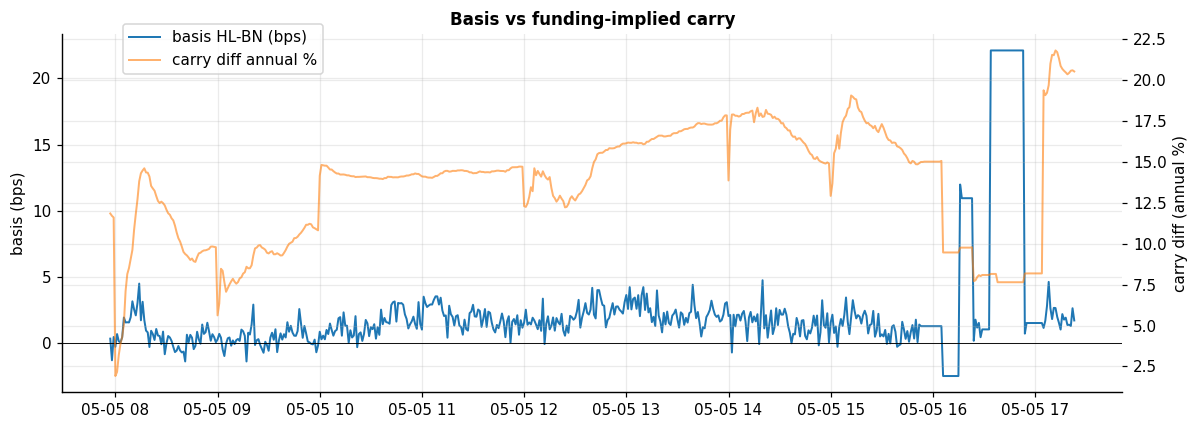

In [6]:
# join funding to basis on minute grid
if not f_hl.empty and not f_bn.empty:
    fhl = f_hl.annual_pct.resample('1min').last().ffill().rename('hl_pct')
    fbn = f_bn.annual_pct.resample('1min').last().ffill().rename('bn_pct')
    df = basis.resample('1min').last().join([fhl,fbn], how='inner').dropna()
    df['carry_diff_pct'] = df.hl_pct - df.bn_pct  # HL - Binance, annualized
    fig, ax1 = plt.subplots(figsize=(11,4))
    ax1.plot(df.index, df.hl_perp_minus_bn_perp_bps, label='basis HL-BN (bps)', color='C0')
    ax1.set_ylabel('basis (bps)'); ax1.axhline(0, color='k', lw=0.6)
    ax2 = ax1.twinx()
    ax2.plot(df.index, df.carry_diff_pct, label='carry diff annual %', color='C1', alpha=0.6)
    ax2.set_ylabel('carry diff (annual %)')
    ax1.set_title('Basis vs funding-implied carry')
    fig.legend(loc='upper left', bbox_to_anchor=(0.1,0.95))
    plt.tight_layout(); plt.show()
else:
    print('Not enough funding rows yet to plot.')